In [1]:
from tensorflow.keras.regularizers import l1, l2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import roc_curve, auc, roc_auc_score,matthews_corrcoef
from tensorflow.keras.callbacks import Callback,EarlyStopping
import random
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, matthews_corrcoef, roc_curve, auc
from tensorflow.keras import backend as K
import itertools
import os
import random
import tensorflow
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, Reshape
from tensorflow.keras.layers import Conv1D,Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras import utils
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import l2
import copy
from sklearn.metrics import roc_auc_score
from Bio import SeqIO
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, Lambda, LSTM
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, TimeDistributed
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau
from numpy import array
from numpy import argmax
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import shuffle
from tensorflow.keras import backend as K
from tensorflow.keras.backend import expand_dims
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l1, l2
from sklearn.metrics import roc_curve, auc, classification_report
from tensorflow.keras.models import load_model
import pandas as pd
from tensorflow.keras.layers import Conv1D,Conv2D, MaxPooling2D,GlobalMaxPooling1D
from Bio import SeqIO
import random
import functools
import itertools
import os
import random
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, Reshape, BatchNormalization
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
import copy   
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras import models,layers,optimizers,regularizers
from sklearn.metrics import accuracy_score

from sklearn.utils import shuffle

os.chdir("/home/t326h379/Prot_T5/After_CD_HIT_deepUBI_protein")

a = random.sample(range(1, 10000), 200)

seed = a[0]

np.random.seed(seed)

aminoacids='ARNDCQEGHILKMFPSTWYV-'

def binary_encode(Sequence_one_hot_encoding): 
    aa2v={x:y for x,y in zip(aminoacids,np.eye(21,21).tolist())}
    aa2v['X']=np.zeros(21)
    encoding=[]
    for i in range(len(Sequence_one_hot_encoding)):
        s=Sequence_one_hot_encoding[i]
        encoding.append([aa2v[x] for x in s])
    encoding=np.array(encoding)
    return encoding

aminoacids='ARNDCQEGHILKMFPSTWYV-'
aaindex=pd.read_table('aaindex31.txt',sep='\s+',header=None)
aaindex=aaindex.subtract(aaindex.min(axis=1),axis=0).divide((aaindex.max(axis=1)-aaindex.min(axis=1)),axis=0)
aa=[x for x in 'ARNDCQEGHILKMFPSTWYV']
aaindex=aaindex.to_numpy().T
index={x:y for x,y in zip(aa,aaindex.tolist())}
index['-']=np.zeros(31).tolist()
index['X']=np.zeros(31).tolist()

def index_encode(Sequence_one_hot_encoding):
    encoding=[]
    for i in range(len(Sequence_one_hot_encoding)):
        s=Sequence_one_hot_encoding[i]
        encoding.append([index[x] for x in (s)])
    encoding=np.array(encoding)
    return encoding



df = pd.read_csv("54181_Positive_DeepUBI_Ubiquitylation_Training_Prot_T5.txt")

y_train_positive = np.array(df["Target"])

train_positive_sequence = list(df["Sequence"])

positive_data = df.drop(["Unnamed: 0","PID","Position","Sequence","Middel AA (K)","Target"], axis=1)
positive_data = np.array(positive_data)

df_negative = pd.read_csv("50170_Negative_DeepUBI_Ubiquitylation_Training_Prot_T5.txt")    
y_train_negative = np.array(df_negative["Target"])

train_negative_sequence = list(df_negative["Sequence"])

negative_data = df_negative.drop(["Unnamed: 0","PID","Position","Sequence","Middel AA (K)","Target"], axis=1)
negative_data = np.array(negative_data)

y_train = list(y_train_positive)+list(y_train_negative)
y_train = np.array(y_train)

train = np.vstack((positive_data,negative_data))
train_sequence = train_positive_sequence+train_negative_sequence
# train, y_train, train_sequence = shuffle(train, y_train, train_sequence, random_state=42)

dictionary_Training_Set = dict(zip(train_sequence,train))

from Bio import SeqIO
import numpy as np

cut_off = int(16)

alphabet = 'ARNDCQEGHILKMFPSTWYV-'

# Independent Testing
indep_test_x_81 = []
indep_test_y_81 = []
posit_1 = 1;
negat_0 = 0;


char_to_int = dict((c, i) for i, c in enumerate(alphabet))
int_to_char = dict((i, c) for i, c in enumerate(alphabet))

def inner1():
    #Input
    data = seq_record.seq

    for char in data:
        if char not in alphabet:
            return
    integer_encoded = [char_to_int[char] for char in data]
    indep_test_x_81.append(integer_encoded)
    indep_test_y_81.append(posit_1)
for seq_record in SeqIO.parse("Positive_10_percent_independent_test_set_DeepUBI.fasta", "fasta"):
    inner1()

def inner2():
    #Input
    data = seq_record.seq

    for char in data:
        if char not in alphabet:
            return
    integer_encoded = [char_to_int[char] for char in data]
    indep_test_x_81.append(integer_encoded)
    indep_test_y_81.append(negat_0)
for seq_record in SeqIO.parse("Negative_10_percent_independent_test_set_DeepUBI.fasta", "fasta"):
    inner2()

# Changing to array (matrix)    
indep_test_x_81 = np.array(indep_test_x_81)
indep_test_y_81 = np.array(indep_test_y_81)

print(indep_test_x_81.shape,indep_test_y_81.shape)

AAindex_Test_AAAAA_81_Sequence = []
for i in range(len(indep_test_x_81)):
    integer_of_string = str(indep_test_x_81[i])
    integer_of_string = integer_of_string.strip("[").strip("]").strip(" ")
    keras_job = integer_of_string.split()
    individual_AA_peptide = []
    for i in range(len(keras_job)):
        index_value = int(keras_job[i])
        individual_AA_peptide.append(int_to_char.get(index_value))
    individual_AA_peptide = "".join(individual_AA_peptide)
    AAindex_Test_AAAAA_81_Sequence.append(individual_AA_peptide) 

Prot_T5_XXX_indi_test = []
for i in range(len(AAindex_Test_AAAAA_81_Sequence)):
    AAindex_Train_AA = AAindex_Test_AAAAA_81_Sequence[i]
    seq = AAindex_Train_AA
    value_of_the_sequence = dictionary_Training_Set.get(seq)
    Prot_T5_XXX_indi_test.append(value_of_the_sequence)

Prot_T5_XXX_indi_test = np.array(Prot_T5_XXX_indi_test)
yval = indep_test_y_81

x_ind_49 = indep_test_x_81[:,[i for i in range(16,65)]]

AAindex_indi_AA_Sequence = []
for i in range(len(x_ind_49)):
    integer_of_string = str(x_ind_49[i])
    integer_of_string = integer_of_string.strip("[").strip("]").strip(" ")
    keras_job = integer_of_string.split()
    individual_AA_peptide = []
    for i in range(len(keras_job)):
        index_value = int(keras_job[i])
        individual_AA_peptide.append(int_to_char.get(index_value))
    individual_AA_peptide = "".join(individual_AA_peptide)
    AAindex_indi_AA_Sequence.append(individual_AA_peptide) 

binaryCoding_Independent_Test = binary_encode(AAindex_indi_AA_Sequence)

AAindexCoding_Independent_Test = index_encode(AAindex_indi_AA_Sequence)

from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import confusion_matrix

2025-06-06 12:09:02.766670: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(12598, 81) (12598,)


# tSNE on Independnet Test Dataset

In [2]:
AAindexCoding_Independent_Test.shape

(12598, 49, 31)

In [3]:
binaryCoding_Independent_Test.shape

(12598, 49, 21)

In [4]:
x_ind_49.shape

(12598, 49)

In [5]:
model = tf.keras.models.load_model('DeepUBI_AAindex_One_Hot_Emb_drop_out2423.h5')

2025-06-06 12:13:34.247260: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2027] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 8.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2025-06-06 12:13:34.255830: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2027] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 8.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2025-06-06 12:13:35.415697: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22278 MB memory:  -> device: 0, name: NVIDIA A30, pci bus id: 0000:65:00.0, compute capability: 8.0


In [6]:
model.summary()

Model: "functional_221"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_444 (InputLayer)         [(None, 49)]         0           []                               
                                                                                                  
 embedding_110 (Embedding)      (None, 49, 21)       483         ['input_444[0][0]']              
                                                                                                  
 conv1d_331 (Conv1D)            (None, 49, 256)      5632        ['embedding_110[0][0]']          
                                                                                                  
 max_pooling1d_331 (MaxPooling1  (None, 24, 256)     0           ['conv1d_331[0][0]']             
 D)                                                                                  

In [12]:
from tensorflow.keras.models import Model

intermediate_layer_model = Model(inputs=model.input,
                             outputs=model.get_layer(index=28).output)

intermediate_layer_model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_444 (InputLayer)         [(None, 49)]         0           []                               
                                                                                                  
 embedding_110 (Embedding)      (None, 49, 21)       483         ['input_444[0][0]']              
                                                                                                  
 conv1d_331 (Conv1D)            (None, 49, 256)      5632        ['embedding_110[0][0]']          
                                                                                                  
 max_pooling1d_331 (MaxPooling1  (None, 24, 256)     0           ['conv1d_331[0][0]']             
 D)                                                                                         

In [13]:
intermediate_output = intermediate_layer_model.predict([AAindexCoding_Independent_Test,binaryCoding_Independent_Test,x_ind_49])

2025-06-06 12:16:29.401240: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401


 33/394 [=>............................] - ETA: 0s   

2025-06-06 12:16:30.360581: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


394/394 [==============================] - 3s 2ms/step


In [21]:
intermediate_output.shape

(12598, 6)

In [22]:
print(seed)

1609


In [23]:
yval.shape

(12598,)

In [24]:
%matplotlib inline

1609


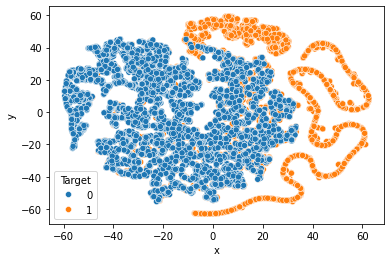

In [25]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame()
df['Target'] = yval

df['Target'].value_counts()

from sklearn.manifold import TSNE
m = TSNE(learning_rate = 50)
tsne_features = m.fit_transform(intermediate_output)
df['x'] = tsne_features[:,0]
df['y'] = tsne_features[:,1]
sns.scatterplot(x="x",y="y",hue='Target',data=df)
filename = "TSNE_MMUbiPred"+str(seed)+".png"
plt.savefig(filename,dpi=350,bbox_inches='tight')
print(seed)
plt.show()
print("\n\n\n")

In [26]:
pwd

'/homes/t326h379/Prot_T5/After_CD_HIT_deepUBI_protein'

# tSNE on training dataset

In [27]:
from tensorflow.keras.regularizers import l1, l2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import roc_curve, auc, roc_auc_score,matthews_corrcoef
from tensorflow.keras.callbacks import Callback,EarlyStopping
import random
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, matthews_corrcoef, roc_curve, auc
from tensorflow.keras import backend as K
import itertools
import os
import random
import tensorflow
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, Reshape
from tensorflow.keras.layers import Conv1D,Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras import utils
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import l2
import copy
from sklearn.metrics import roc_auc_score
from Bio import SeqIO
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, Lambda, LSTM
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, TimeDistributed
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau
from numpy import array
from numpy import argmax
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import shuffle
from tensorflow.keras import backend as K
from tensorflow.keras.backend import expand_dims
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l1, l2
from sklearn.metrics import roc_curve, auc, classification_report
from tensorflow.keras.models import load_model
import pandas as pd
from tensorflow.keras.layers import Conv1D,Conv2D, MaxPooling2D,GlobalMaxPooling1D
from Bio import SeqIO
import random
import functools
import itertools
import os
import random
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, Reshape, BatchNormalization
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
import copy   
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras import models,layers,optimizers,regularizers
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

os.chdir("/home/t326h379/Prot_T5/After_CD_HIT_deepUBI_protein")

a = random.sample(range(1, 10000), 200)

seed = a[0]

np.random.seed(seed)



df = pd.read_csv("54181_Positive_DeepUBI_Ubiquitylation_Training_Prot_T5.txt")

y_train_positive = np.array(df["Target"])

train_positive_sequence = list(df["Sequence"])

positive_data = df.drop(["Unnamed: 0","PID","Position","Sequence","Middel AA (K)","Target"], axis=1)
positive_data = np.array(positive_data)

df_negative = pd.read_csv("50170_Negative_DeepUBI_Ubiquitylation_Training_Prot_T5.txt")    
y_train_negative = np.array(df_negative["Target"])

train_negative_sequence = list(df_negative["Sequence"])

negative_data = df_negative.drop(["Unnamed: 0","PID","Position","Sequence","Middel AA (K)","Target"], axis=1)
negative_data = np.array(negative_data)

y_train = list(y_train_positive)+list(y_train_negative)
y_train = np.array(y_train)

train = np.vstack((positive_data,negative_data))
train_sequence = train_positive_sequence+train_negative_sequence
# train, y_train, train_sequence = shuffle(train, y_train, train_sequence, random_state=42)

from Bio import SeqIO
import numpy as np

cut_off = int(16)

alphabet = 'ARNDCQEGHILKMFPSTWYV-'

train_x_81 = []
train_y_81 = []
posit_1 = 1;
negat_0 = 0;


char_to_int = dict((c, i) for i, c in enumerate(alphabet))
int_to_char = dict((i, c) for i, c in enumerate(alphabet))

def inner1():
    #Input
    data = seq_record.seq

#     data = data[cut_off:-cut_off]

    for char in data:
        if char not in alphabet:
            return
    integer_encoded = [char_to_int[char] for char in data]
    train_x_81.append(integer_encoded)
    train_y_81.append(posit_1)
for seq_record in SeqIO.parse("Positive_90_percent_training_set_DeepUBI.fasta", "fasta"):
    inner1()

def inner2():
    #Input
    data = seq_record.seq

#     data = data[cut_off:-cut_off]

    for char in data:
        if char not in alphabet:
            return
    integer_encoded = [char_to_int[char] for char in data]
    train_x_81.append(integer_encoded)
    train_y_81.append(negat_0)
for seq_record in SeqIO.parse("Negative_90_percent_training_set_DeepUBI.fasta", "fasta"):
    inner2()

# Changing to array (matrix)    
train_x_81 = np.array(train_x_81)
train_y_81 = np.array(train_y_81)

rus = RandomUnderSampler(random_state=seed)
train_x_81, train_y_81 = rus.fit_resample(train_x_81, train_y_81)

x_train_49 = train_x_81[:,[i for i in range(16,65)]]

AAindex_Train_AA_Sequence = []
for i in range(len(x_train_49)):
    integer_of_string = str(x_train_49[i])
    integer_of_string = integer_of_string.strip("[").strip("]").strip(" ")
    keras_job = integer_of_string.split()
    individual_AA_peptide = []
    for i in range(len(keras_job)):
        index_value = int(keras_job[i])
        individual_AA_peptide.append(int_to_char.get(index_value))
    individual_AA_peptide = "".join(individual_AA_peptide)
    AAindex_Train_AA_Sequence.append(individual_AA_peptide) 

aminoacids='ARNDCQEGHILKMFPSTWYV-'

def binary_encode(Sequence_one_hot_encoding): 
    aa2v={x:y for x,y in zip(aminoacids,np.eye(21,21).tolist())}
    aa2v['X']=np.zeros(21)
    encoding=[]
    for i in range(len(Sequence_one_hot_encoding)):
        s=Sequence_one_hot_encoding[i]
        encoding.append([aa2v[x] for x in s])
    encoding=np.array(encoding)
    return encoding

binaryCoding_Training = binary_encode(AAindex_Train_AA_Sequence)

aminoacids='ARNDCQEGHILKMFPSTWYV-'
aaindex=pd.read_table('aaindex31.txt',sep='\s+',header=None)
aaindex=aaindex.subtract(aaindex.min(axis=1),axis=0).divide((aaindex.max(axis=1)-aaindex.min(axis=1)),axis=0)
aa=[x for x in 'ARNDCQEGHILKMFPSTWYV']
aaindex=aaindex.to_numpy().T
index={x:y for x,y in zip(aa,aaindex.tolist())}
index['-']=np.zeros(31).tolist()
index['X']=np.zeros(31).tolist()

def index_encode(Sequence_one_hot_encoding):
    encoding=[]
    for i in range(len(Sequence_one_hot_encoding)):
        s=Sequence_one_hot_encoding[i]
        encoding.append([index[x] for x in (s)])
    encoding=np.array(encoding)
    return encoding

AAindexCoding_Training = index_encode(AAindex_Train_AA_Sequence)

dictionary_Training_Set = dict(zip(train_sequence,train))

AAindex_Train_AA_81_Sequence = []
for i in range(len(train_x_81)):
    integer_of_string = str(train_x_81[i])
    integer_of_string = integer_of_string.strip("[").strip("]").strip(" ")
    keras_job = integer_of_string.split()
    individual_AA_peptide = []
    for i in range(len(keras_job)):
        index_value = int(keras_job[i])
        individual_AA_peptide.append(int_to_char.get(index_value))
    individual_AA_peptide = "".join(individual_AA_peptide)
    AAindex_Train_AA_81_Sequence.append(individual_AA_peptide) 

Prot_T5_X_train = []
for i in range(len(AAindex_Train_AA_81_Sequence)):
    AAindex_Train_AA = AAindex_Train_AA_81_Sequence[i]
    seq = AAindex_Train_AA
    value_of_the_sequence = dictionary_Training_Set.get(seq)
    Prot_T5_X_train.append(value_of_the_sequence)

Prot_T5_X_train = np.array(Prot_T5_X_train)

#$$$$$$$$$$$$$$$$$$$$$$$
# Shuffle
#$$$$$$$$$$$$$$$$$$$$$$
binaryCoding_Training, Prot_T5_X_train, AAindexCoding_Training, x_train_49, train_y_81 = shuffle(binaryCoding_Training, Prot_T5_X_train, AAindexCoding_Training, x_train_49, train_y_81, random_state = seed)

In [28]:
AAindexCoding_Training.shape

(90272, 49, 31)

In [29]:
train_y_81.shape

(90272,)

In [31]:
intermediate_output = intermediate_layer_model.predict([AAindexCoding_Training,binaryCoding_Training,x_train_49])

2821/2821 [==============================] - 4s 2ms/step


In [32]:
intermediate_output.shape

(90272, 6)

4006


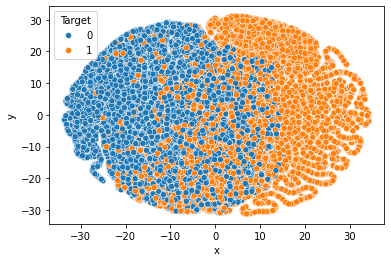

In [33]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame()
df['Target'] = train_y_81

df['Target'].value_counts()

from sklearn.manifold import TSNE
m = TSNE(learning_rate = 50)
tsne_features = m.fit_transform(intermediate_output)
df['x'] = tsne_features[:,0]
df['y'] = tsne_features[:,1]
sns.scatterplot(x="x",y="y",hue='Target',data=df)
filename = "TSNE_MMUbiPred_Training"+str(seed)+".png"
plt.savefig(filename,dpi=350,bbox_inches='tight')
print(seed)
plt.show()
print("\n\n\n")